### This is for better visualization. plotly is somewhat pissing me off in R, so instead lets use a mix of R and python

In [ ]:
library(janitor)
library(readr)
library(tidyverse)
library(rPref)

Warning message:
"Paket 'janitor' wurde unter R Version 4.4.1 erstellt"

Attache Paket: 'janitor'


Die folgenden Objekte sind maskiert von 'package:stats':

    chisq.test, fisher.test


Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'purrr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'forcats' wurde unter R Version 4.4.1 erstellt"
-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v purrr     1.2.1
v forcats   1.0.1     v stringr   1.5.1
v ggplot2   4.0.2     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"Paket 'rPref' wurde unter R Version 4.4.1 erstellt"

Attache Paket: 'rPref'


D

In [ ]:
results <- read_csv("data/results/brfss_w_svi/ctree_results.csv")
results_rf <- read_csv("data/results/brfss_w_svi/rf_results.csv")
results_xgb <- read_csv("data/results/brfss_w_svi/xgb_results.csv")

Rows: 91 Columns: 8
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl (8): FNloss, cp, precision, precision_std, recall, recall_std, accuracy,...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 40 Columns: 8
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl (8): mtry, cutoff, precision, precision_std, recall, recall_std, accurac...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 360 Columns: 9
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl (9): max_depth, eta, cutoff, precision, precision_std, recall, recall_st...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types o

In [ ]:
p <- high(precision, df = results) * high(recall) * high(accuracy)
res <- psel(results, p)
res <- res[order(res$precision), ]
res
res <- res %>% select(precision, recall, accuracy)
write_csv(res, "data/results/brfss_w_svi/ctree_pareto.csv")

res_rf <- psel(results_rf, p)
res_rf <- res_rf[order(res_rf$precision), ]
res_rf <- res_rf %>% select(precision, recall, accuracy)
write_csv(res_rf, "data/results/brfss_w_svi/rf_pareto.csv")

res_xgb <- psel(results_xgb, p)
res_xgb <- res_xgb[order(res_xgb$precision), ]
res_xgb <- res_xgb %>% select(precision, recall, accuracy)
write_csv(res_xgb, "data/results/brfss_w_svi/xgb_pareto.csv")

FNloss,cp,precision,precision_std,recall,recall_std,accuracy,accuracy_std
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5.3,0.0003766456,0.8398478,0.07376497,0.9823529,0.05580490,0.8942857,0.06245783
5.7,0.0000000000,0.8398478,0.07376497,0.9823529,0.05580490,0.8942857,0.06245783
9.6,0.0015155041,0.8487165,0.07999154,0.9764706,0.05682893,0.8971429,0.06250228
4.3,0.0000000000,0.8499679,0.07613516,0.9529412,0.06678191,0.8884034,0.06028308
3.6,0.0000000000,0.8580942,0.08420259,0.9470588,0.06473558,0.8884874,0.06023132
1.1,0.0000000000,0.9050650,0.07722623,0.9352941,0.07568729,0.9149580,0.05954579
1.5,0.0000000000,0.9060079,0.08079048,0.9176471,0.06904634,0.9060504,0.05694727
1.2,0.0000000000,0.9154388,0.07801011,0.9117647,0.07964744,0.9089916,0.05965801


In [13]:
from scipy.spatial import ConvexHull
import pandas as pd
import plotly.graph_objects as go

df_ctree = pd.read_csv('data/results/brfss_w_svi/ctree_results.csv')
df_opt_ct = pd.read_csv('data/results/brfss_w_svi/ctree_pareto.csv')

points_ct = df_opt_ct[['precision', 'recall', 'accuracy']].values
hull = ConvexHull(points_ct)

fig = go.Figure()

# All points (blue)
fig.add_trace(go.Scatter3d(
    x=df_ctree['precision'],
    y=df_ctree['recall'],
    z=df_ctree['accuracy'],
    mode='markers',
    marker=dict(color='blue', size=4, opacity=0.5),
    name='All models'
))

# Convex hull as a 3D mesh
fig.add_trace(go.Mesh3d(
    x=points_ct[:, 0],
    y=points_ct[:, 1],
    z=points_ct[:, 2],
    i=hull.simplices[:, 0],
    j=hull.simplices[:, 1],
    k=hull.simplices[:, 2],
    opacity=0.4,
    color='red',
    name='Pareto hull'
))

# Optionally overlay the hull vertices as red points
fig.add_trace(go.Scatter3d(
    x=points_ct[hull.vertices, 0],
    y=points_ct[hull.vertices, 1],
    z=points_ct[hull.vertices, 2],
    mode='markers',
    marker=dict(color='red', size=6),
    name='Pareto vertices'
))

fig.update_layout(scene=dict(
    xaxis_title='Precision',
    yaxis_title='Recall',
    zaxis_title='Accuracy'
))
fig.show()

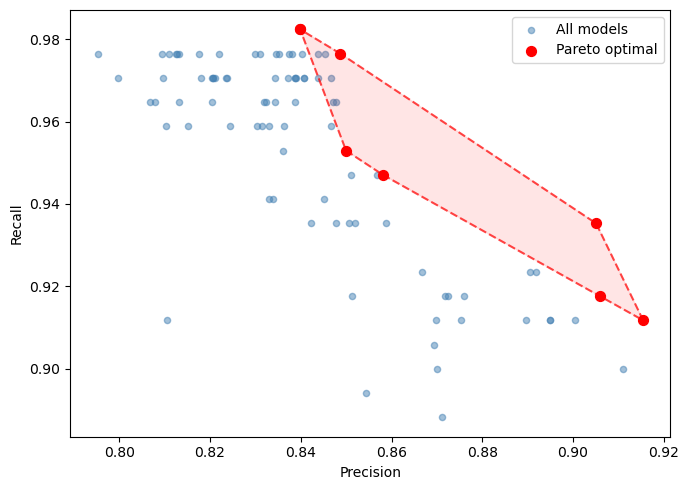

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import numpy as np

df_ctree = pd.read_csv('data/results/brfss_w_svi/ctree_results.csv')
df_opt_ct = pd.read_csv('data/results/brfss_w_svi/ctree_pareto.csv')

points_2d = df_opt_ct[['precision', 'recall']].values
hull = ConvexHull(points_2d)
hull_pts = np.append(hull.vertices, hull.vertices[0])

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df_ctree['precision'], df_ctree['recall'],
           color='steelblue', s=20, alpha=0.5, label='All models')

ax.scatter(df_opt_ct['precision'], df_opt_ct['recall'],
           color='red', s=50, zorder=5, label='Pareto optimal')

ax.plot(points_2d[hull_pts, 0], points_2d[hull_pts, 1],
        'r--', linewidth=1.5, alpha=0.7)

ax.fill(points_2d[hull.vertices, 0], points_2d[hull.vertices, 1],
        alpha=0.1, color='red')

ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.legend()
plt.tight_layout()
plt.show()